### Training with **Colab** — Multi-Model Version

In [7]:
!pip install imagehash dotenv tensorboard -q

In [8]:
import os
import torch
import importlib
import pandas as pd
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from torch.utils.tensorboard import SummaryWriter


### Environment setup

In [9]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Cloud-Based Environment: {IN_COLAB}")

if IN_COLAB:
    env = "colab"
    DATA_PATH = '/content/Dl-net/data/'

    # Mount Google Drive so logs/checkpoints survive runtime disconnects
    drive.mount('/content/drive')

    # Get token securely instead of hardcoding it
    token = None
    try:
        from google.colab import userdata
        token = userdata.get('GITHUB_TOKEN')
    except Exception:
        pass

    if not token:
        from getpass import getpass
        token = getpass("Enter your GitHub token: ")

    if not os.path.isdir('/content/Dl-net'):
        !git clone https://{token}@github.com/sadbinsiddique/Dl-net.git

    os.chdir('/content/Dl-net')
else:
    env = "local"
    DATA_PATH = './'
    print("Local environment detected")


Cloud-Based Environment: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


++++++++++++++++++++++++++++++++++++++++++++++++++
Step 01: [data init]
++++++++++++++++++++++++++++++++++++++++++++++++++


[1]Dataset: data/casme2-preprocessed-v2


[2]Dataset: data/ckplusferdata


[3]Dataset: data/sammassamexpression
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/ckplusferdata
[2]Found 35887 total files.


> Extracting Metadata: 100%|██████████| 35887/35887 [00:04<00:00, 8037.24it/s]


[4]Valid images: 35887 | Corrupted: 0


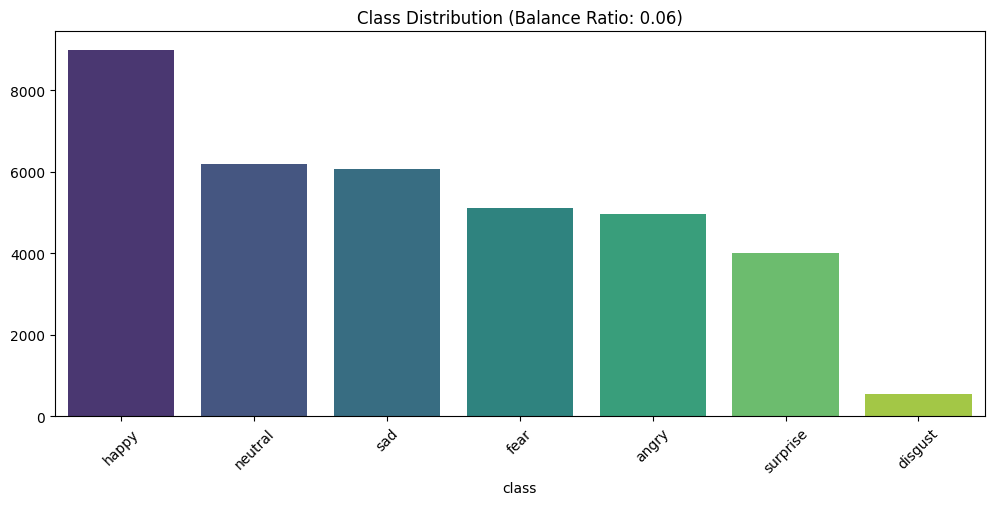

[5]Calculating image metrics...


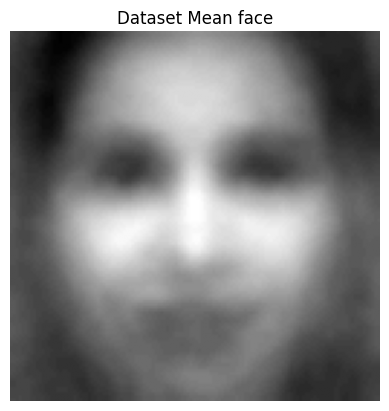

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 13463.82it/s]


[7]Running t-SNE...


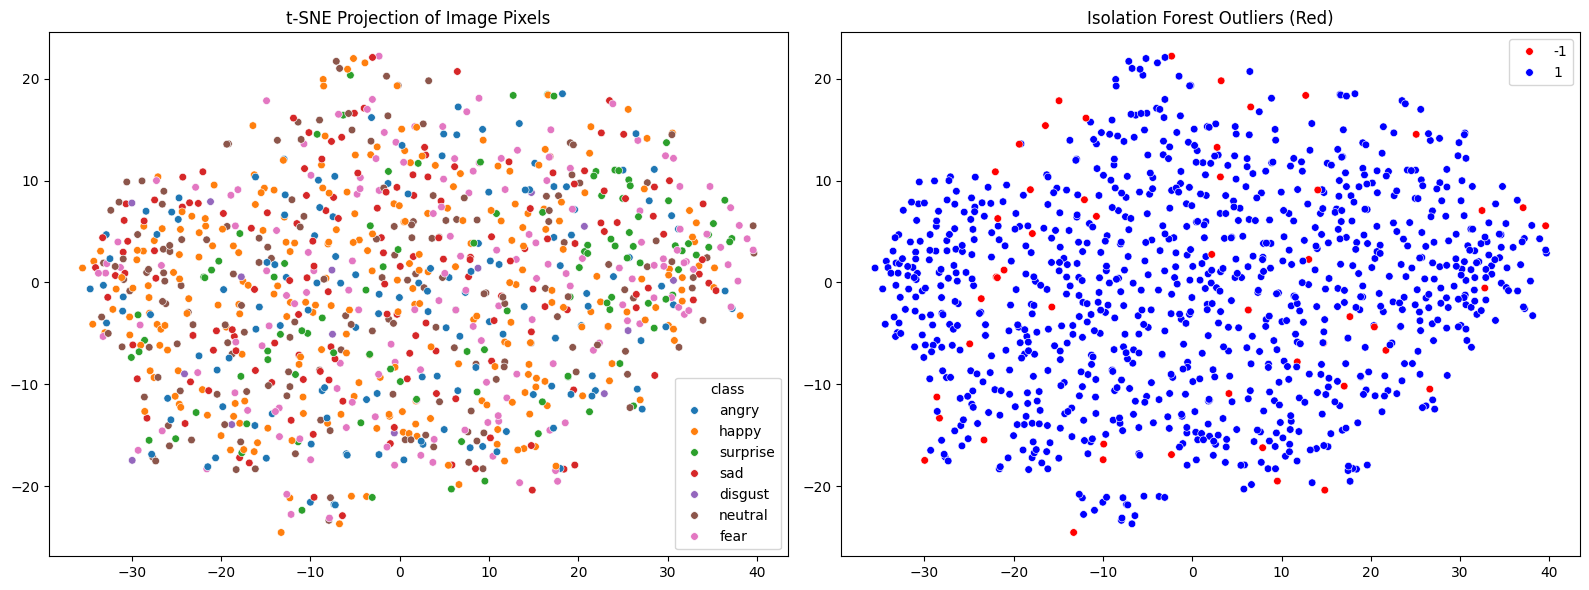

[8]./data/ckplusferdata/eda.csv saved successfully.
[9]EDA for ckplus saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64

Middle Sample Size: 5121
BALANCED CLASS DISTRIBUTION
class
angry       5121
disgust     5121
fear        5121
happy       5121
neutral     5121
sad         5121
surprise    5121
Name: count, dtype: int64

Balanced Dataset Shape: (35847, 14)
Train Shape : (28709, 14)
Test Shape  : (7178, 14)
[10]Data Balance for ckplus saved successfully.
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/sammassamexpression
[2]Found 23565 total files.


> Extracting Metadata: 100%|██████████| 23565/23565 [00:04<00:00, 5192.69it/s]


[4]Valid images: 23565 | Corrupted: 0


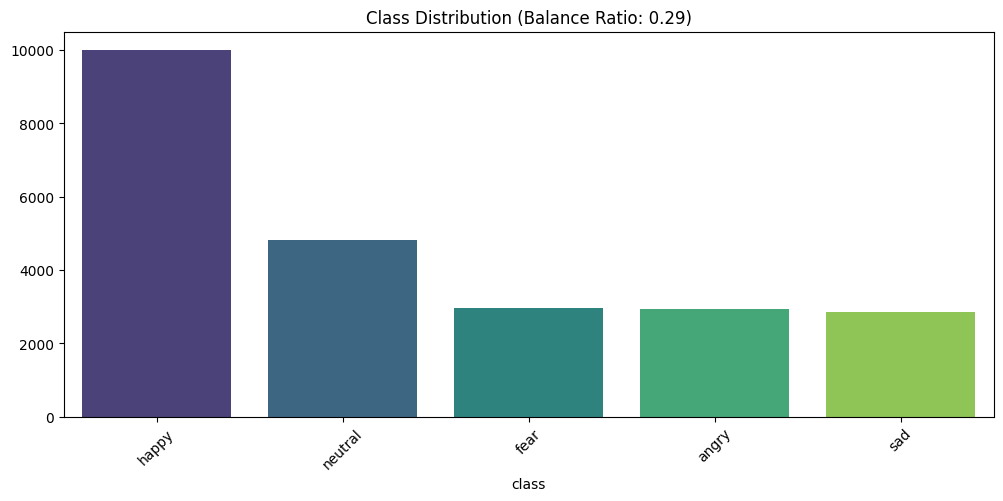

[5]Calculating image metrics...


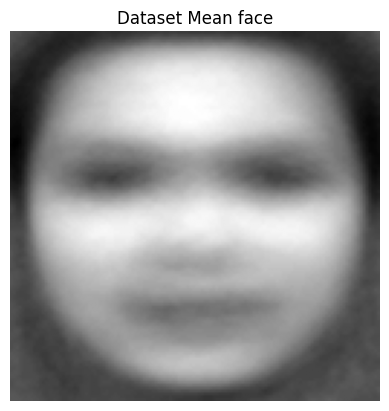

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 3824.13it/s]


[7]Running t-SNE...


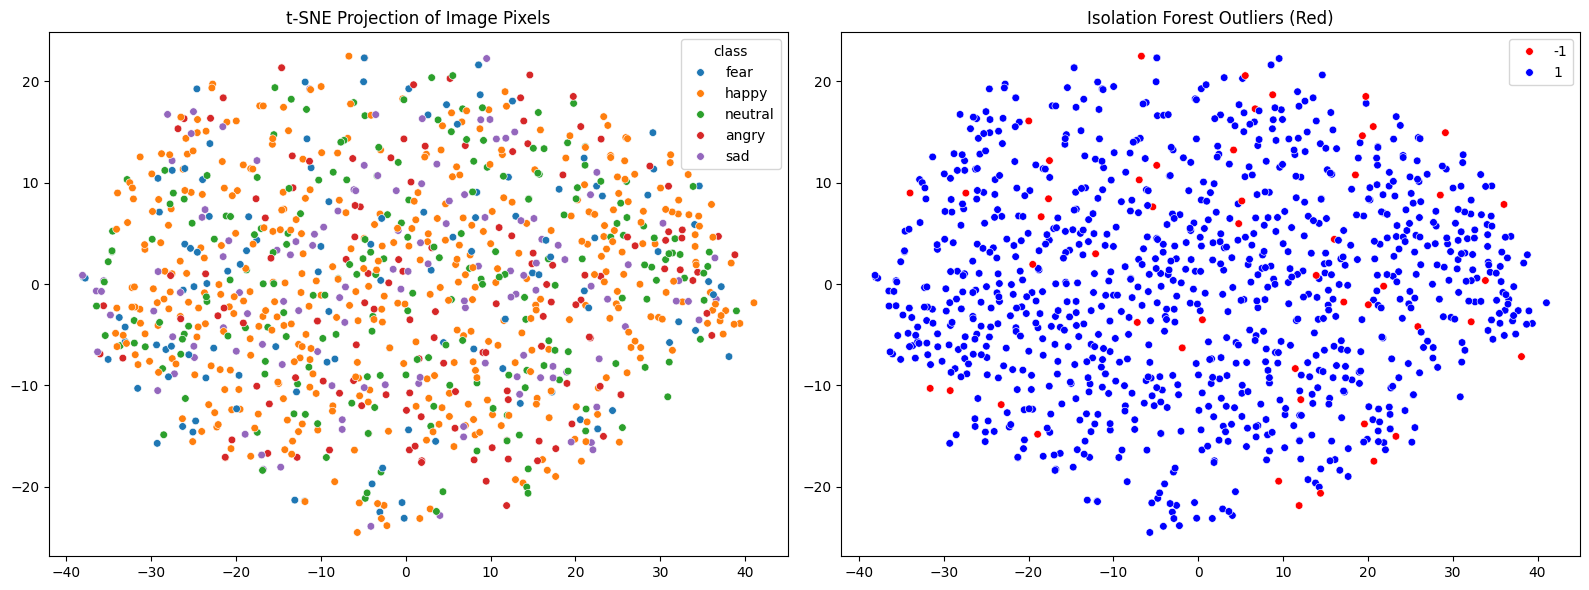

[8]./data/sammassamexpression/eda.csv saved successfully.
[9]EDA for samm saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       2940
fear        2954
happy      10001
neutral     4815
sad         2855
Name: count, dtype: int64

Middle Sample Size: 2954
BALANCED CLASS DISTRIBUTION
class
angry      2954
fear       2954
happy      2954
neutral    2954
sad        2954
Name: count, dtype: int64

Balanced Dataset Shape: (14770, 14)
Train Shape : (18852, 14)
Test Shape  : (4713, 14)
[10]Data Balance for samm saved successfully.
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/casme2-preprocessed-v2
[2]Found 17019 total files.


> Extracting Metadata: 100%|██████████| 17019/17019 [00:03<00:00, 4756.27it/s]


[4]Valid images: 17019 | Corrupted: 0


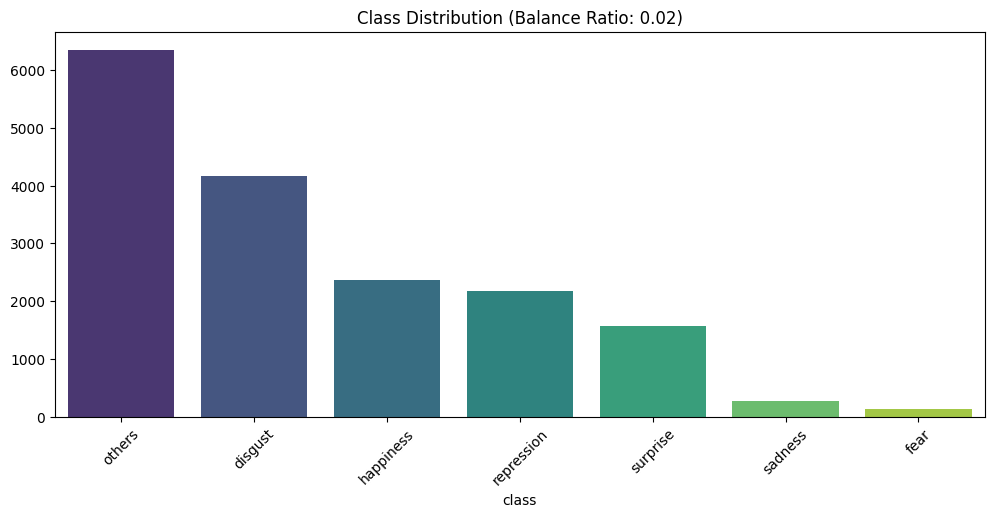

[5]Calculating image metrics...


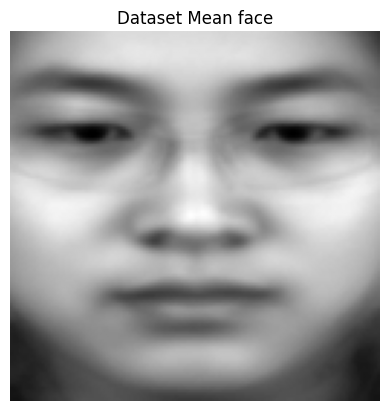

MediaPipe base not installed. Skipping face landmarking.
[6]Flattening images for PCA, t-SNE, and Isolation Forest


100%|██████████| 1000/1000 [00:00<00:00, 1956.83it/s]


[7]Running t-SNE...


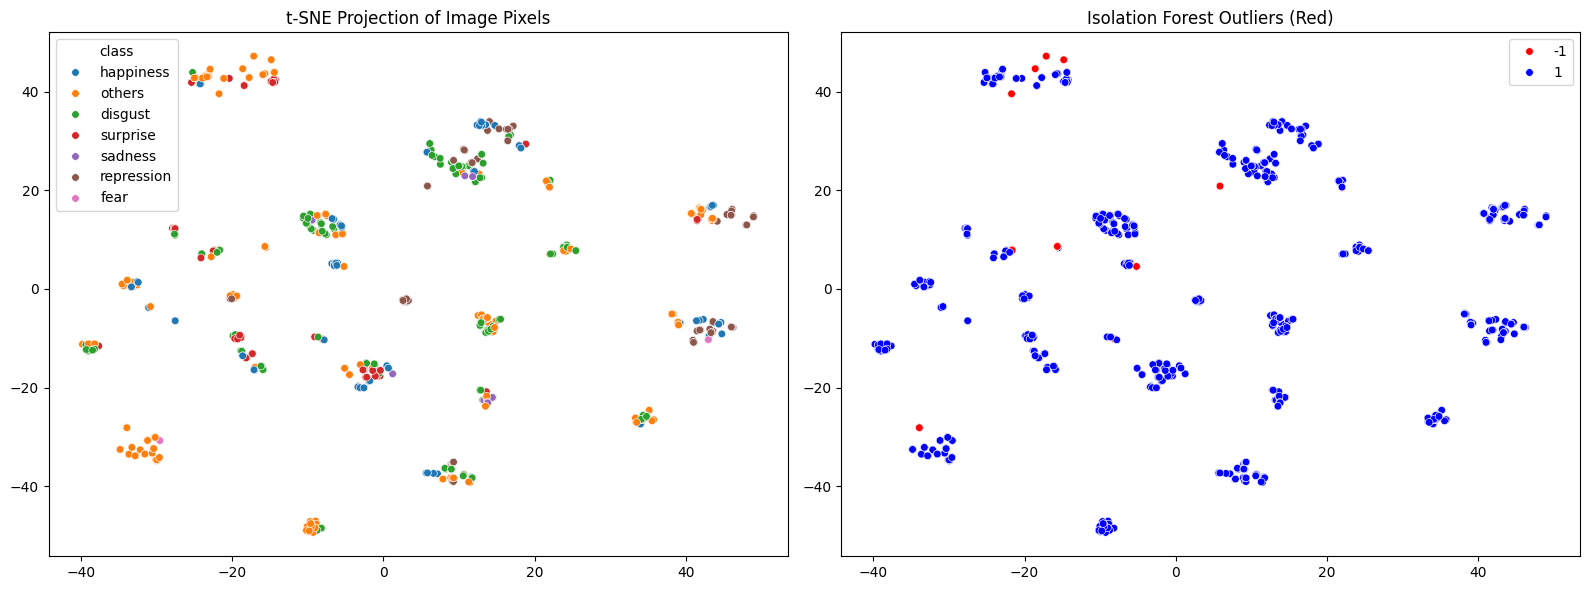

[8]./data/casme2-preprocessed-v2/eda.csv saved successfully.
[9]EDA for casme2 saved successfully.
ORIGINAL CLASS DISTRIBUTION
class
angry       2178
disgust     4159
fear         127
happy       2360
neutral     6344
sad          274
surprise    1577
Name: count, dtype: int64

Middle Sample Size: 2178
BALANCED CLASS DISTRIBUTION
class
angry       2178
disgust     2178
fear        2178
happy       2178
neutral     2178
sad         2178
surprise    2178
Name: count, dtype: int64

Balanced Dataset Shape: (15246, 14)
Train Shape : (13615, 14)
Test Shape  : (3404, 14)
[10]Data Balance for casme2 saved successfully.


In [10]:
!sed -i 's/^from eda import \*/from .eda import \*/' /content/Dl-net/src/utils/eda_imp.py

from src.utils import pipeline
importlib.reload(pipeline)
from src.utils.pipeline import _run_pipeline
_run_pipeline()


### Main Code

In [11]:
train_df = pd.read_csv("/content/Dl-net/data/casme2-preprocessed-v2/train.csv")
test_df = pd.read_csv("/content/Dl-net/data/casme2-preprocessed-v2/test.csv")
test = test_df[["filepath","class"]].copy()
train = train_df[["filepath","class"]].copy()

label_encoder = LabelEncoder()
train['class'] = label_encoder.fit_transform(train['class'])
test['class'] = label_encoder.transform(test['class'])

CLASS_NAMES = label_encoder.classes_
NUM_CLASSES_GLOBAL = len(CLASS_NAMES)

print(f"Train shape      : {train.shape}")
print(f"Test shape       : {test.shape}")
print(f"Classes          : {list(CLASS_NAMES)}")


Train shape      : (13615, 2)
Test shape       : (3404, 2)
Classes          : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])])


In [13]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df.loc[idx, "filepath"]).convert("RGB")
        label = int(self.df.loc[idx, "class"])

        if self.transform:
            image = self.transform(image)

        return image, label


In [14]:
train_dataset = EmotionDataset(train, train_transform)
val_dataset = EmotionDataset(test, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


## Model Zoo

In [15]:
def get_model(model_name, num_classes):
    """
    Returns a pretrained model with the final layer replaced for num_classes.
    Supported: 'alexnet', 'vit', 'mobilenetv3', 'efficientnet', 'convnext'
    """
    if model_name == "alexnet":
        model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif model_name == "vit":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

    elif model_name == "mobilenetv3":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    elif model_name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "convnext":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model


## Train all 5 models



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ALL_MODELS = ["alexnet", "vit", "mobilenetv3", "efficientnet", "convnext"]
EPOCHS_PER_MODEL = 20

LOG_ROOT = "/content/drive/MyDrive/tensorboard_runs"
os.makedirs(LOG_ROOT, exist_ok=True)

results = {}

for name in ALL_MODELS:
    print(f"\n===== Training {name} =====")

    model = get_model(name, NUM_CLASSES_GLOBAL).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    log_dir = f"{LOG_ROOT}/{name}"
    writer = SummaryWriter(log_dir)

    best_acc = 0.0

    for epoch in range(EPOCHS_PER_MODEL):

        # ---- Train ----
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0

        train_loop = tqdm(train_loader, desc=f"[{name}] Epoch {epoch+1}/{EPOCHS_PER_MODEL} - Train")
        for images, labels in train_loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
            train_loop.set_postfix(loss=loss.item())

        train_loss = running_loss / train_total
        train_acc = train_correct / train_total

        # ---- Validate ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # ---- Log ----
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"Epoch {epoch+1}/{EPOCHS_PER_MODEL} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            checkpoint_path = f"{LOG_ROOT}/{name}_best.pth"
            torch.save(model.state_dict(), checkpoint_path)

    writer.close()
    results[name] = best_acc
    print(f"Finished {name}. Best val accuracy: {best_acc:.4f}")

    # Free GPU memory before starting the next model
    del model, optimizer
    torch.cuda.empty_cache()

print("\n===== Summary =====")
for name, acc in results.items():
    print(f"{name:12s}: {acc:.4f}")


Using device: cuda

===== Training alexnet =====
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 149MB/s]
[alexnet] Epoch 1/20 - Train: 100%|██████████| 426/426 [00:55<00:00,  7.64it/s, loss=0.488]


Epoch 1/20 | Train Loss: 0.8758 Acc: 0.6555 | Val Loss: 0.4115 Acc: 0.8525


[alexnet] Epoch 2/20 - Train: 100%|██████████| 426/426 [00:48<00:00,  8.87it/s, loss=0.304]


Epoch 2/20 | Train Loss: 0.3256 Acc: 0.8765 | Val Loss: 0.2831 Acc: 0.8869


...

[convnext] Epoch 2/20 - Train: 100%|██████████| 426/426 [03:53<00:00,  1.82it/s, loss=0.0234]


Epoch 2/20 | Train Loss: 0.0986 Acc: 0.9675 | Val Loss: 0.0612 Acc: 0.9768


[convnext] Epoch 3/20 - Train: 100%|██████████| 426/426 [03:53<00:00,  1.83it/s, loss=0.17]


Epoch 3/20 | Train Loss: 0.0591 Acc: 0.9805 | Val Loss: 0.0252 Acc: 0.9888


[convnext] Epoch 4/20 - Train:  36%|███▋      | 155/426 [01:25<02:29,  1.81it/s, loss=0.041]

## View results in TensorBoard

Points at the parent `tensorboard_runs` folder in Drive, so all 5 trained models show up together for comparison.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/drive/MyDrive/tensorboard_runs
